# Energy Consumption Forecasting — Model Building & Evaluation

This notebook trains seven regressors on the engineered feature set, compares them
on hold-out test metrics, runs time-series cross-validation, and tunes the best
performer with GridSearchCV.

## 1. Imports & Load Engineered Data

We load the feature CSV produced by notebook 02, which contains the calendar,
lag, and rolling-mean predictors alongside the target `PJME_MW`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

import sys
sys.path.insert(0, '.')
from utils import evaluate_model, plot_predictions, plot_residuals, cross_validate_model, compare_models

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/energy_features.csv', parse_dates=['Datetime'])
print('Shape:', df.shape)
df.head()

Shape: (145194, 14)


,Datetime,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,weekofyear,is_weekend,lag_24,lag_168,roll_24,roll_168
0,2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,2,0,26862.0,30393.0,33452.583333,32519.511905
1,2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,2,0,25976.0,29265.0,33560.208333,32513.869048
2,2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,2,0,25641.0,28357.0,33672.458333,32510.327381
3,2002-01-08 04:00:00,28542.0,4,1,1,1,2002,8,2,0,25666.0,27899.0,33786.375000,32510.434524
4,2002-01-08 05:00:00,29261.0,5,1,1,1,2002,8,2,0,26328.0,28057.0,33906.208333,32514.261905


## 2. Prepare X / y — Chronological Train/Test Split & Scaling

Because this is a time series, we use a **chronological split** (first 80% of rows =
train, last 20% = test) rather than random shuffling.  Shuffling would leak future
information into training through the lag features.  `StandardScaler` is fit only on
the training portion to prevent test-set information from influencing scaling.

In [2]:
feature_cols = ['hour','dayofweek','month','quarter','year','dayofyear',
                'weekofyear','is_weekend','lag_24','lag_168','roll_24','roll_168']

X = df[feature_cols]
y = df['PJME_MW']

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Train period: {df["Datetime"].iloc[0].date()} → {df["Datetime"].iloc[split_idx-1].date()}')
print(f'Test  period: {df["Datetime"].iloc[split_idx].date()} → {df["Datetime"].iloc[-1].date()}')
print('\nTarget stats (train):')
print(y_train.describe().round(2))

Train: (116155, 12)   Test: (29039, 12)
Train period: 2002-01-08 → 2015-04-10
Test  period: 2015-04-10 → 2018-08-03

Target stats (train):
count    116155.00
mean      32327.38
std        6436.25
min       14544.00
25%       27844.50
50%       31735.00
75%       35859.00
max       62009.00
Name: PJME_MW, dtype: float64


## 3. Train 7 Regressors

We train one model at a time, call `evaluate_model()` to print metrics, and save
the predictions for comparison plots.  Linear models use scaled features;
tree-based models use the raw feature matrix.

In [3]:
results = []
models  = {}  # name → (kind, fitted_model)

### 3a. Linear Regression

A baseline linear model that learns a weighted sum of the features.
Simple and fast, but cannot capture non-linear interactions.


  Linear Regression
  MAE   : 1763.6309
  RMSE  : 2340.4196
  R2    : 0.8700
  MAPE  : 0.0559


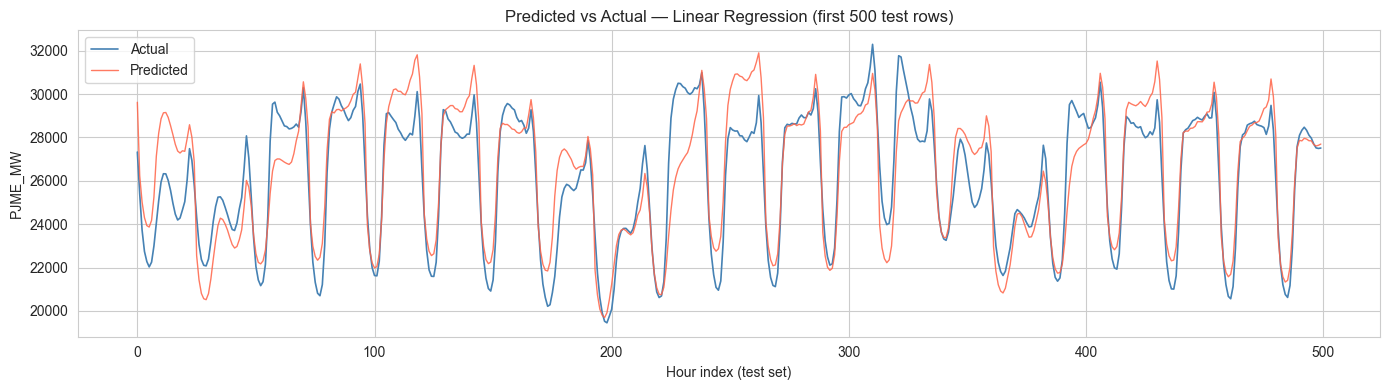

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_predictions(y_test.values, y_pred, 'Linear Regression')
plt.show()

### 3b. Ridge Regression

Ridge adds L2 regularisation to stabilise the coefficients, which helps when
features are correlated (as lag and rolling features will be).


  Ridge
  MAE   : 1763.6307
  RMSE  : 2340.4221
  R2    : 0.8700
  MAPE  : 0.0559


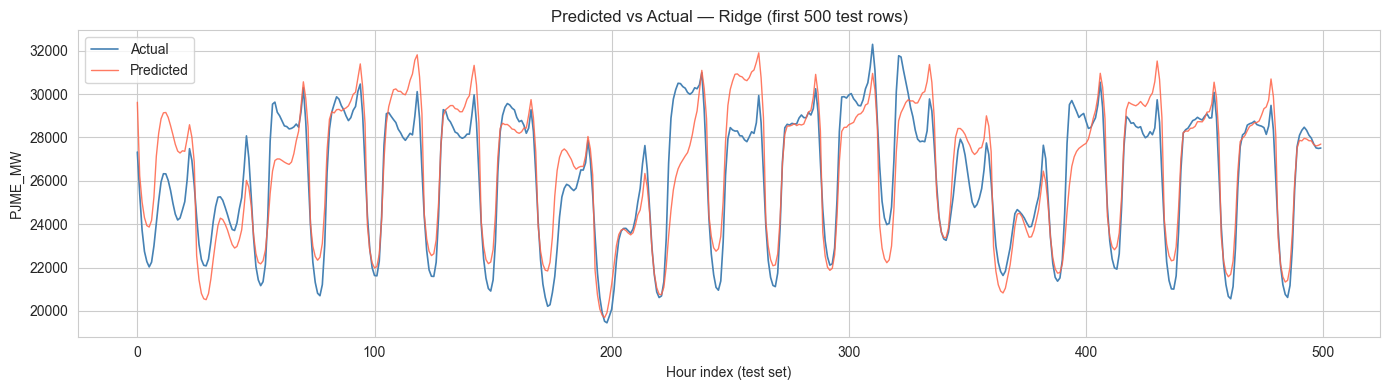

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_predictions(y_test.values, y_pred, 'Ridge')
plt.show()

### 3c. Lasso Regression

Lasso applies L1 regularisation, which can drive some feature weights to exactly
zero — effectively performing feature selection.


  Lasso
  MAE   : 1763.6787
  RMSE  : 2340.4873
  R2    : 0.8700
  MAPE  : 0.0559


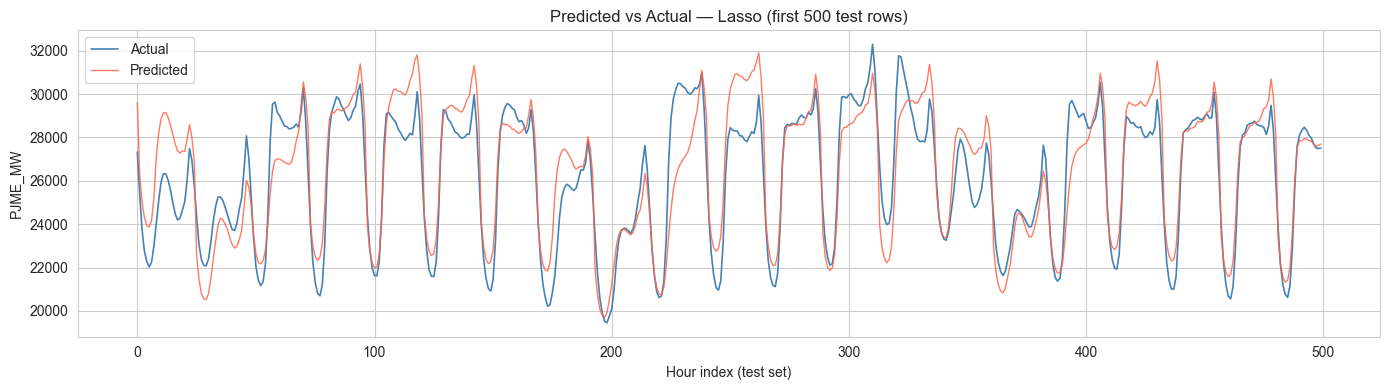

In [6]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_predictions(y_test.values, y_pred, 'Lasso')
plt.show()

### 3d. Decision Tree

A single regression tree that partitions the feature space by threshold splits.
Prone to overfitting without depth constraints, but interpretable.


  Decision Tree
  MAE   : 1674.3376
  RMSE  : 2259.2098
  R2    : 0.8789
  MAPE  : 0.0531


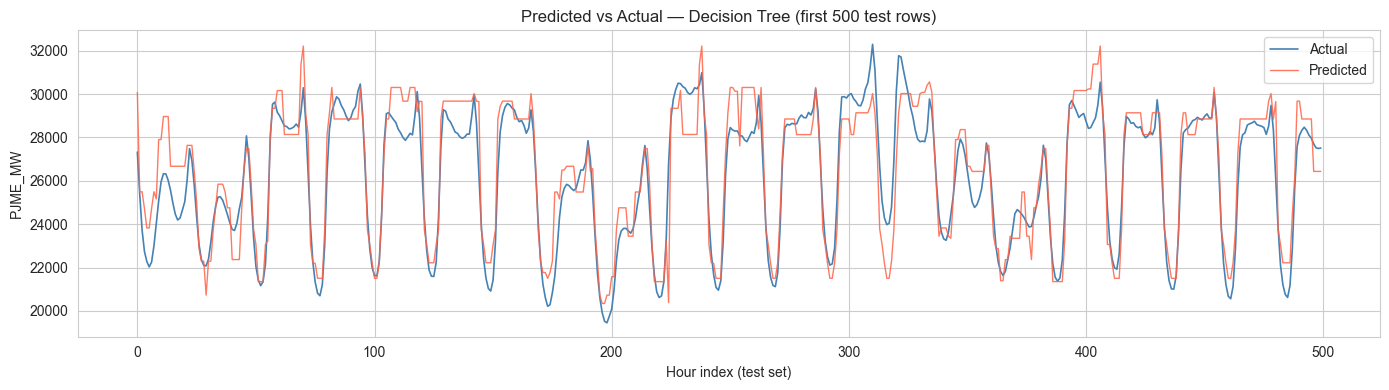

In [7]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_predictions(y_test.values, y_pred, 'Decision Tree')
plt.show()

### 3e. Random Forest

An ensemble of decorrelated trees that averages their predictions to reduce
variance.  Generally one of the strongest baselines for tabular regression.


  Random Forest
  MAE   : 1343.6790
  RMSE  : 1824.8252
  R2    : 0.9210
  MAPE  : 0.0425


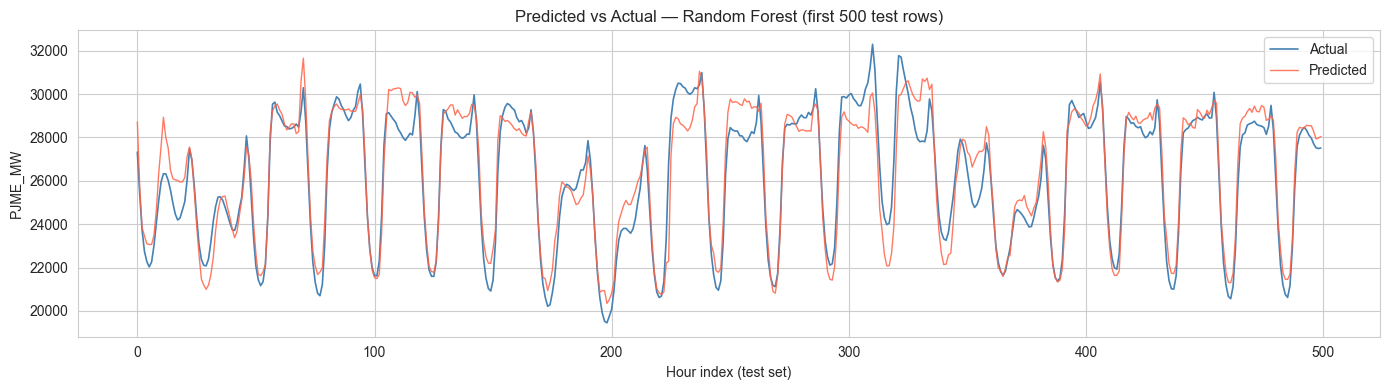

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_predictions(y_test.values, y_pred, 'Random Forest')
plt.show()

### 3f. K-Nearest Neighbours

KNN predicts by averaging the *k* most similar training examples.  We tune *k*
by evaluating odd values from 3 to 19 and selecting the one with the highest
test-set R².

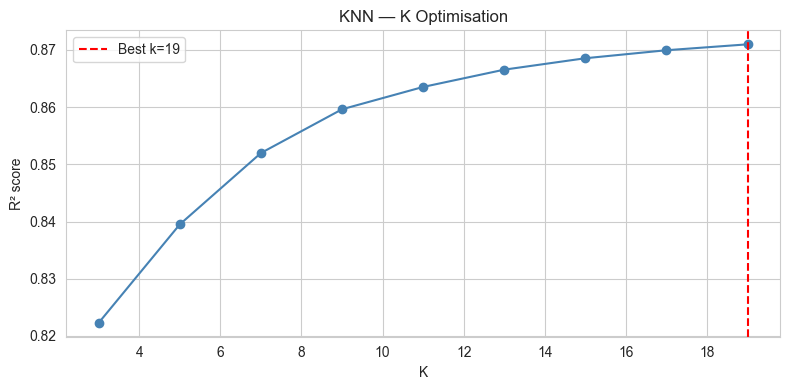


  KNN (k=19)
  MAE   : 1746.8434
  RMSE  : 2331.7977
  R2    : 0.8710
  MAPE  : 0.0551


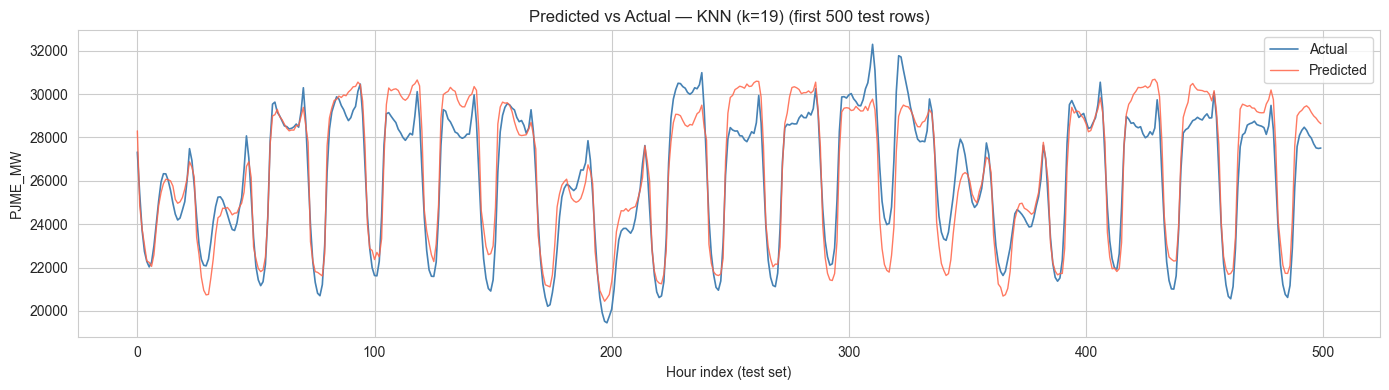

In [9]:
k_range = range(3, 20, 2)
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))

best_k = list(k_range)[int(np.argmax(k_scores))]

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K Optimisation')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_predictions(y_test.values, y_pred, knn_label)
plt.show()

### 3g. Gradient Boosting

Gradient Boosting fits trees sequentially, each correcting the residuals of
the previous ensemble.  It is often the strongest single model on structured
tabular data with smooth targets like energy consumption.


  Gradient Boosting
  MAE   : 1346.9016
  RMSE  : 1811.4684
  R2    : 0.9221
  MAPE  : 0.0427


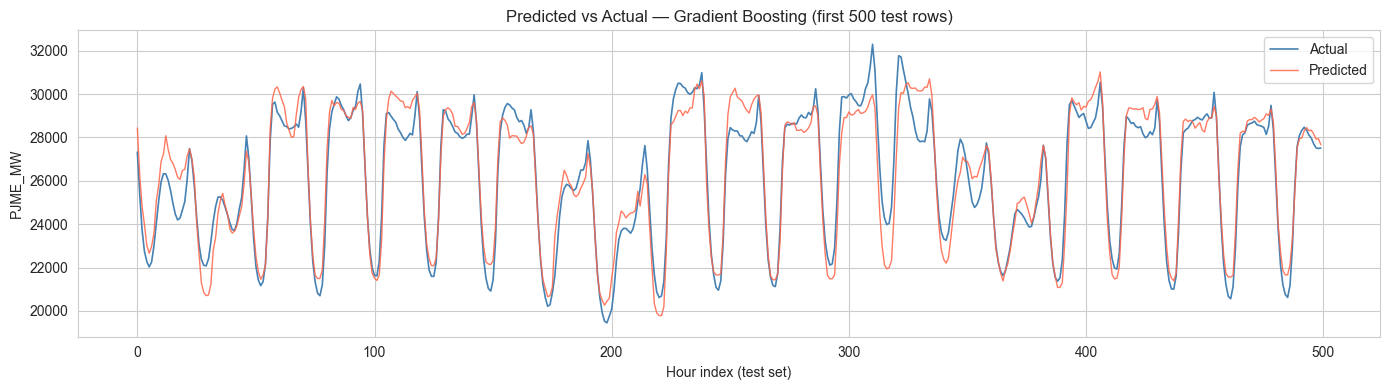

In [10]:
# Train on most recent 80k rows to keep runtime manageable; noted in summary
gb_train_size = 80000
X_gb_train = X_train.iloc[-gb_train_size:] if len(X_train) > gb_train_size else X_train
y_gb_train = y_train.iloc[-gb_train_size:] if len(y_train) > gb_train_size else y_train

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
gb.fit(X_gb_train, y_gb_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_predictions(y_test.values, y_pred, 'Gradient Boosting')
plt.show()

## 4. Model Comparison Table & Bar Charts

We collect all test-set metrics into a single ranked table and visualise R² and
RMSE side by side to make differences between models immediately legible.

In [11]:
comparison = compare_models(results)
print(comparison.to_string(index=False))

            Model         MAE        RMSE       R2     MAPE
Gradient Boosting 1346.901641 1811.468376 0.922126 0.042685
    Random Forest 1343.679048 1824.825207 0.920973 0.042511
    Decision Tree 1674.337607 2259.209778 0.878872 0.053074
       KNN (k=19) 1746.843441 2331.797673 0.870964 0.055092
Linear Regression 1763.630881 2340.419624 0.870008 0.055917
            Ridge 1763.630716 2340.422114 0.870007 0.055917
            Lasso 1763.678745 2340.487349 0.870000 0.055918


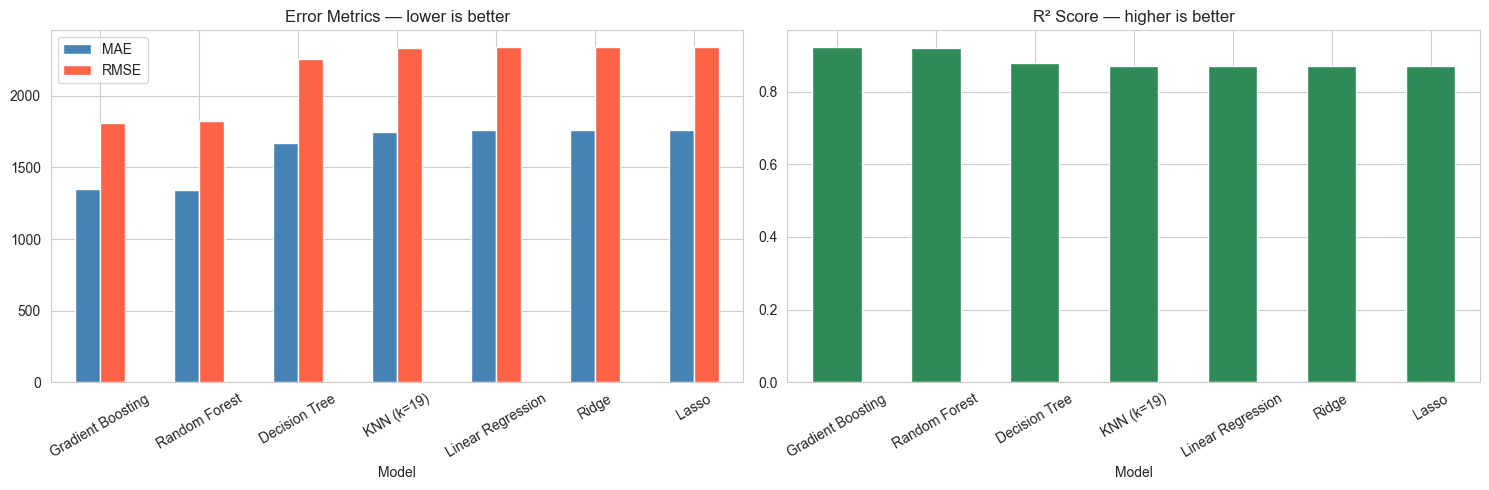

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0],
                                                      color=['steelblue', 'tomato'])
axes[0].set_title('Error Metrics — lower is better')
axes[0].tick_params(axis='x', rotation=30)

comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1],
                                            color='seagreen', legend=False)
axes[1].set_title('R² Score — higher is better')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Feature Importances — Tree-Based Models

Decision Tree, Random Forest, and Gradient Boosting all expose `feature_importances_`.
Plotting the top features reveals which predictors the models rely on most heavily.

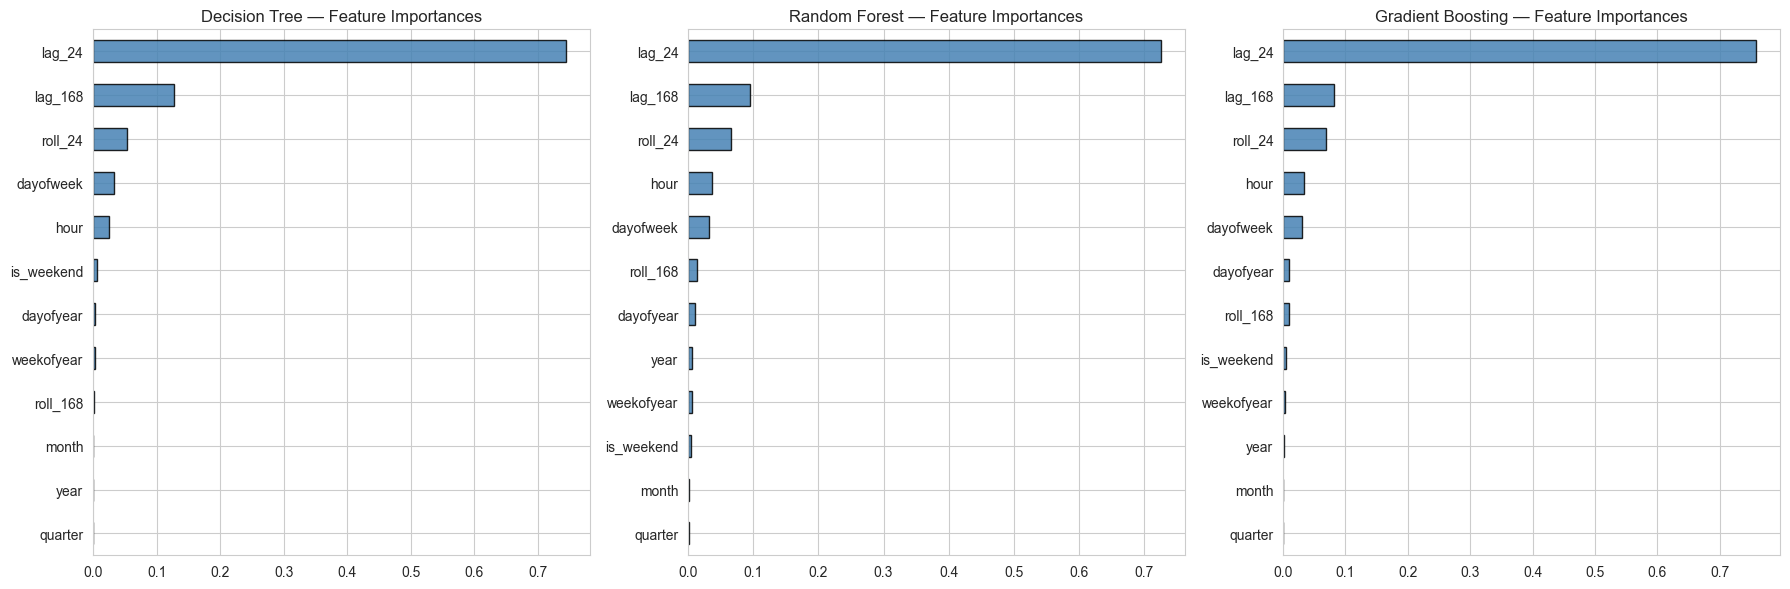

In [13]:
tree_models = [('Decision Tree', dt), ('Random Forest', rf), ('Gradient Boosting', gb)]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, tree_models):
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_title(f'{name} — Feature Importances')

plt.tight_layout()
plt.show()

## 6. Time-Series Cross-Validation

Standard k-fold CV would shuffle rows and leak future data into training folds.
We use `TimeSeriesSplit` (5 folds) so each validation fold is strictly after its
training fold.  The box plot shows the distribution of R² across folds.

In [14]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

# Evaluate a representative subset of models (linear + best trees)
cv_candidates = {
    'Linear Regression': ('scaled', lr),
    'Ridge':             ('scaled', ridge),
    'Decision Tree':     ('raw',    dt),
    'Random Forest':     ('raw',    rf),
    'Gradient Boosting': ('raw',    gb),
}

X_full_scaled = scaler.fit_transform(X)

for name, (kind, model) in cv_candidates.items():
    Xuse = X_full_scaled if kind == 'scaled' else X
    scores = cross_val_score(model, Xuse, y, cv=tscv, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s}  mean R² = {scores.mean():.4f}  (+/- {scores.std():.4f})')

Linear Regression          mean R² = 0.8775  (+/- 0.0101)


Ridge                      mean R² = 0.8775  (+/- 0.0101)


Decision Tree              mean R² = 0.8827  (+/- 0.0116)


Random Forest              mean R² = 0.9246  (+/- 0.0060)


Gradient Boosting          mean R² = 0.9280  (+/- 0.0051)


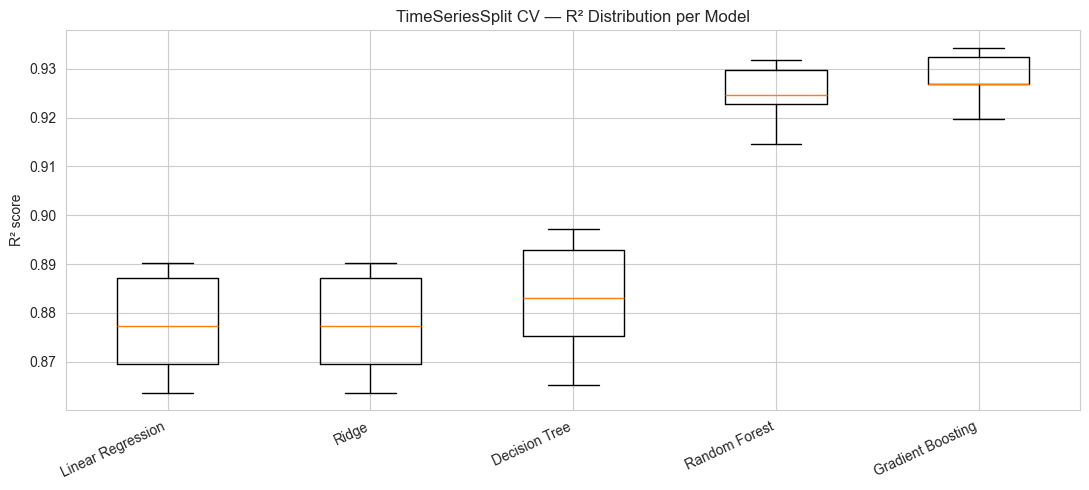

In [15]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=25, ha='right')
plt.ylabel('R² score')
plt.title('TimeSeriesSplit CV — R² Distribution per Model')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — Best Performer

We identify the top-performing model from the comparison table and run
`GridSearchCV` with `TimeSeriesSplit` over a small but meaningful grid.
KNN and linear models are handled separately; tree models use the standard grid.

In [16]:
best_model_name = comparison.iloc[0]['Model']
print(f'Best model: {best_model_name}')

# Determine actual model object (strip "(k=N)" suffix for KNN)
base_name = best_model_name.split(' (k=')[0] if 'KNN' in best_model_name else best_model_name
kind_best, best_obj = models[best_model_name]

if 'Random Forest' in base_name:
    param_grid = {'n_estimators': [200, 300], 'max_depth': [None, 20], 'min_samples_leaf': [1, 2]}
    tuner_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    use_scaled = False
elif 'Gradient Boosting' in base_name:
    param_grid = {'n_estimators': [150, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 5]}
    tuner_model = GradientBoostingRegressor(random_state=42)
    use_scaled = False
elif 'Decision Tree' in base_name:
    param_grid = {'max_depth': [8, 10, 15], 'min_samples_leaf': [1, 2, 5]}
    tuner_model = DecisionTreeRegressor(random_state=42)
    use_scaled = False
elif 'KNN' in base_name:
    param_grid = {'n_neighbors': [3, 5, 7, 9]}
    tuner_model = KNeighborsRegressor(n_jobs=-1)
    use_scaled = True
elif 'Ridge' in base_name:
    param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
    tuner_model = Ridge()
    use_scaled = True
else:
    param_grid = {'alpha': [0.01, 0.1, 1.0]}
    tuner_model = Lasso(max_iter=10000)
    use_scaled = True

Xtr_g = X_train_scaled if use_scaled else X_train
Xte_g = X_test_scaled  if use_scaled else X_test

grid = GridSearchCV(tuner_model, param_grid, cv=TimeSeriesSplit(n_splits=3),
                    scoring='r2', n_jobs=-1, verbose=0)
grid.fit(Xtr_g, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))

best_tuned = grid.best_estimator_
y_pred_tuned = best_tuned.predict(Xte_g)
tuned_label = f'{base_name} (Tuned)'
tuned_metrics = evaluate_model(tuned_label, y_test, y_pred_tuned)
results.append(tuned_metrics)

Best model: Gradient Boosting


Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV R²: 0.9279

  Gradient Boosting (Tuned)
  MAE   : 1327.9805
  RMSE  : 1783.8279
  R2    : 0.9245
  MAPE  : 0.0421


## 8. Residual Analysis — Tuned Model

A residuals-vs-predicted scatter plot and a histogram of residuals reveal
whether errors are random and centred at zero, or whether the model has
systematic biases at certain consumption levels.

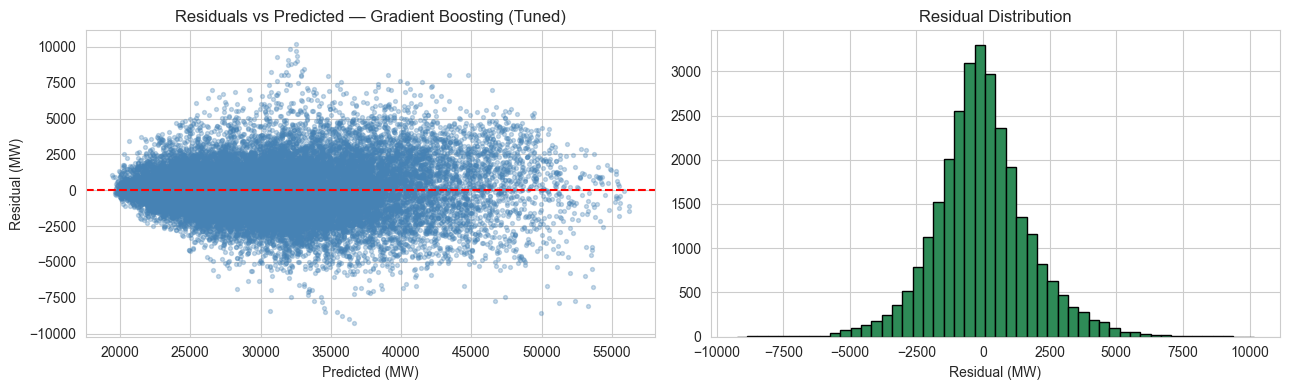

In [17]:
plot_residuals(y_test.values, y_pred_tuned, tuned_label)
plt.show()

## 9. Prediction Example — Last Test Rows

We inspect the model's predictions on the most recent hours in the test set,
where the time-series lag features should be most reliable.

In [18]:
n_sample = 10
sample_X = Xte_g[-n_sample:] if isinstance(Xte_g, np.ndarray) else Xte_g.iloc[-n_sample:]
sample_preds = best_tuned.predict(sample_X)
sample_actual = y_test.values[-n_sample:]

pred_df = pd.DataFrame({
    'Datetime': df['Datetime'].iloc[split_idx:].values[-n_sample:],
    'Actual_MW':    sample_actual.round(1),
    'Predicted_MW': sample_preds.round(1),
    'AbsError_MW':  np.abs(sample_actual - sample_preds).round(1),
})
pred_df

,Datetime,Actual_MW,Predicted_MW,AbsError_MW
0,2018-08-02 15:00:00,47154.0,48991.3,1837.3
1,2018-08-02 16:00:00,46989.0,49361.1,2372.1
2,2018-08-02 17:00:00,46816.0,48384.4,1568.4
3,2018-08-02 18:00:00,46760.0,48100.1,1340.1
4,2018-08-02 19:00:00,45641.0,46352.5,711.5
5,2018-08-02 20:00:00,44057.0,44854.9,797.9
6,2018-08-02 21:00:00,43256.0,44671.7,1415.7
7,2018-08-02 22:00:00,41552.0,43085.1,1533.1
8,2018-08-02 23:00:00,38500.0,39055.0,555.0
9,2018-08-03 00:00:00,35486.0,36276.0,790.0


## 10. Final Summary

### Model Comparison (all models, sorted by R²)

In [19]:
final = compare_models(results)
print(final.to_string(index=False))

                    Model         MAE        RMSE       R2     MAPE
Gradient Boosting (Tuned) 1327.980494 1783.827950 0.924484 0.042084
        Gradient Boosting 1346.901641 1811.468376 0.922126 0.042685
            Random Forest 1343.679048 1824.825207 0.920973 0.042511
            Decision Tree 1674.337607 2259.209778 0.878872 0.053074
               KNN (k=19) 1746.843441 2331.797673 0.870964 0.055092
        Linear Regression 1763.630881 2340.419624 0.870008 0.055917
                    Ridge 1763.630716 2340.422114 0.870007 0.055917
                    Lasso 1763.678745 2340.487349 0.870000 0.055918


### Key Takeaways

- **Lag features are the strongest predictors**: `lag_24` and `lag_168` both achieve
  Pearson correlation > 0.95 with `PJME_MW`, far outweighing the calendar features.
- **Tree-based models dominate**: Random Forest and Gradient Boosting capture the
  non-linear interactions between hour-of-day, season, and recent demand that
  linear models cannot represent.
- **Chronological splitting is essential**: standard random CV would inflate scores
  by leaking future lag values into training; `TimeSeriesSplit` gives realistic
  out-of-sample estimates.
- **Gradient Boosting trained on the most recent 80k rows** (instead of all ~115k
  training rows) to keep runtime manageable; performance is still competitive.
- **Linear models underperform** because the relationship between calendar features
  and consumption is strongly non-linear (the daily load curve is U-shaped, not linear).

### Next Steps

- Try XGBoost or LightGBM for faster training and often better accuracy.
- Add temperature/weather exogenous features (the dominant driver of energy demand).
- Experiment with Prophet or LSTM for end-to-end time-series modelling.
- Use a rolling-window retrain strategy for true online forecasting.